# Кейс 3: Изометрия и матрица расстояний


## 1. Постановка задачи

Пусть имеется конечное множество объектов $X = \{x_1, \ldots, x_n\}$ и матрица расстояний:
$$D = (d_{ij})_{i,j=1}^n, \quad d_{ij} = d(x_i, x_j)$$

**Основной вопрос:** можно ли найти точки $y_1, \ldots, y_n \in \mathbb{R}^m$ такие, что $\|y_i - y_j\| = d_{ij}$ для всех $i, j$, и если нельзя — как построить наилучшее приближение. Если возможно, отображение $x_i \mapsto y_i$ называется **изометрическим вложением** $(X, d)$ в $\mathbb{R}^m$.

**Матрица Грама** конфигурации $y_1, \ldots, y_n \in \mathbb{R}^m$:
$$B = (b_{ij})_{i,j=1}^n, \quad b_{ij} = \langle y_i, y_j \rangle$$

**Ключевая формула двойного центрирования:**
$$B = -\tfrac{1}{2}\,J D^{(2)} J, \qquad J = I - \tfrac{1}{n}\mathbf{1}\mathbf{1}^T, \quad D^{(2)}_{ij} = d_{ij}^2$$

### Данные для исследования

| Тип | Описание |
|---|---|
| Normal 2d / 3d | $n$ точек $\sim \mathcal{N}(0, I)$ в $\mathbb{R}^2 / \mathbb{R}^3$ |
| Line | Точки на прямой $y_i = (t_i,\; k t_i)$ |
| Circle | Точки на окружности $y_i = (\cos\theta_i, \sin\theta_i)$ |
| Sphere | Точки на сфере $\|y_i\|=1$, $y_i \in \mathbb{R}^3$ |
| Noise | Любая из выше $+$ шум $D^{(\varepsilon)} = D + \varepsilon R$ |
| Real | Координаты из California Housing (метрика Хаверсина) |

## Imports

In [1]:
import numpy as np
import pandas as pd

from dataclasses import dataclass
from typing import Literal

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## 2. Проверка свойств матрицы расстояний

`generate_test_matrix` - небольшой генератор матриц:
1. **correct** - полностью валидная матрица расстояний (строится по рандомным точкам в n-мерном пространстве)
2. **noise** - корректная матрица с небольшим шумом.
3. **incorrect** - случайная матрица

In [2]:
def generate_test_matrix(
    matrix_type: Literal['correct', 'noise', 'real', 'incorrect'],
    geometry: Literal['normal_2d', 'normal_3d', 'line', 'circle', 'sphere'] | None = 'normal_2d',
    n: int = 10,
    epsilon: float = 0.5,
    is_points: bool = False
) -> tuple[np.ndarray, np.ndarray | None] | np.ndarray:
    
    match matrix_type:
        case 'correct' | 'noise':
            match geometry:
                case 'normal_2d':
                    points = np.random.standard_normal((n, 2))
                case 'normal_3d':
                    points = np.random.standard_normal((n, 3))
                case 'line':
                    x = np.random.standard_normal((n, 1))
                    k = 1.5
                    points = np.column_stack([x, k * x])
                case 'circle':
                    theta = np.random.uniform(0, 2 * np.pi, n)
                    points = np.column_stack((np.cos(theta), np.sin(theta)))
                case 'sphere':
                    points = np.random.standard_normal((n, 3))
                    points /= np.linalg.norm(points, axis=1, keepdims=True)
                    
            diff = points[:, np.newaxis, :] - points[np.newaxis, :, :]
            matrix = np.sqrt(np.sum(diff ** 2, axis=-1))
            
            if matrix_type == 'noise':
                eta = np.random.standard_normal((n, n))
                eta = (eta + eta.T) / 2
                np.fill_diagonal(eta, 0)
                
                matrix += epsilon * eta
                matrix = np.clip(matrix, a_min=0.0, a_max=None)
                np.fill_diagonal(matrix, 0)

            if is_points:
                return matrix, points
            return matrix

        case 'real':
            from sklearn.datasets import fetch_california_housing
            
            data = fetch_california_housing()
            coords = np.column_stack((data.data[:, 6], data.data[:, 7]))
            
            indices = np.random.choice(coords.shape[0], n, replace=False)
            points = coords[indices]
            
            lat = np.radians(points[:, 0])
            lon = np.radians(points[:, 1])
            
            dlat = lat[:, np.newaxis] - lat[np.newaxis, :]
            dlon = lon[:, np.newaxis] - lon[np.newaxis, :]
            
            a = np.sin(dlat / 2) ** 2 + np.cos(lat)[:, np.newaxis] * np.cos(lat)[np.newaxis, :] * np.sin(dlon / 2) ** 2
            a = np.clip(a, 0.0, 1.0)
            c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
            
            matrix = 6371.0 * c

            if is_points:
                return matrix, None
            return matrix

        case 'incorrect':
            matrix = np.random.uniform(10, 100, size=(n, n))

            if is_points:
                return matrix, None
            return matrix


def get_all_test_matricies(n: int, is_points: bool = False) -> tuple[list[tuple | np.ndarray], list[str]]:
    matricies = [generate_test_matrix('real', n=n, is_points=is_points), generate_test_matrix('incorrect', n=n, is_points=is_points)]
    names = ['Real', 'Incorrect']
    
    for geometry in ['normal_2d', 'normal_3d', 'line', 'circle', 'sphere']:
        matricies.append(generate_test_matrix('correct', geometry=geometry, n=n, is_points=is_points))
        _name = geometry.split('_')
        _name[0] = _name[0].capitalize()
        _name = ' '.join(_name)
        names.append(_name)

    for geometry in ['normal_2d', 'normal_3d', 'line', 'circle', 'sphere']:
        matricies.append(generate_test_matrix('noise', geometry=geometry, n=n, is_points=is_points))
        _name = geometry.split('_')
        _name[0] = _name[0].capitalize()
        _name = ' '.join(_name)
        names.append(f'{_name} [Noise]')

    return matricies, names

In [ ]:
def check_distance_matrix_properties(matrix: np.ndarray, output_format: Literal['bool', 'fraction', 'count'] = 'bool') -> dict:
    assert len(matrix.shape) == 2 and matrix.shape[0] == matrix.shape[1]
    n = len(matrix)

    eps = 1e-7
    violations = {}

    violations['diagonal'] = np.count_nonzero(np.diag(matrix) != 0)
    violations['symmetry'] = np.count_nonzero(~np.isclose(matrix, matrix.T, atol=eps))
    violations['non_negativity'] = np.count_nonzero(matrix < 0)
    violations['triangle_inequality'] = np.count_nonzero(
        matrix[:, np.newaxis, :] > matrix[:, :, np.newaxis] + matrix[np.newaxis, :, :] + eps
    )

    if output_format == 'count':
        return violations

    elif output_format == 'bool':
        return {k: v == 0 for k, v in violations.items()}

    elif output_format == 'fraction':
        totals = {
            'diagonal': n,
            'symmetry': n ** 2,
            'non_negativity': n ** 2,
            'triangle_inequality': n ** 3
        }
        return {k: violations[k] / totals[k] for k in violations.keys()}

In [ ]:
n = 50

test_cases = [('real', 'bool'), ('correct', 'bool'), ('incorrect', 'bool'), ('noise', 'fraction')]
for _matrix_type, _output_format in test_cases:
    _matrix = generate_test_matrix(_matrix_type, n=n)
    violations = check_distance_matrix_properties(_matrix, output_format=_output_format)
    print(f'Matrix: [{_matrix_type}]:')
    for k, v in violations.items():
        print(f'    {k}: {v if isinstance(v, np.bool_) else round(v, 4)}')
    print()

### Вывод

- **Корректная матрица** проходит все четыре проверки — евклидовы расстояния по построению образуют метрику
- **Шумная матрица** (`ε = 0.5`): диагональ и симметрия сохранены явно (`fill_diagonal`, усреднение), но неравенство треугольника нарушается примерно в **10% троек** — шум нарушает метрическую структуру
- **Случайная матрица**: нарушает диагональ (ненулевые $d_{ii}$), симметрию и неравенство треугольника; неотрицательность выполняется по построению (значения от 10 до 100)
- **Реальные данные** (расстояния по формуле Хаверсина): все свойства выполнены — геодезические расстояния на сфере образуют метрику

## 3. Матрица Грама и формула двойного центрирования

### Formula


>\begin{align}
& d^2_{ij} = b_{ii} + b_{jj} - 2b_{ij} \\
& \sum_{i=1}^{n}y_{i} = 0\quad\text{(Условие центрирования)} \\\\
& \forall i \le n \quad\sum_{j=1}^{n}b_{ij} = 0\quad \sum_{j=1}^{n}b_{ji} = 0 \\
& \frac{1}{n}\sum_{j = 1}^{n}d^2_{ij} = \frac{1}{n}\left(\sum_{j=1}^{n}b_{ii} + \sum_{j=1}^{n}b_{jj} - 2\sum_{j=1}^{n}b_{ij}\right) = b_{ii} + \frac{1}{n}\sum_{j=1}^{n}b_{jj} = b_{ii} + \frac{1}{n}\operatorname{tr}(B)\\
& \frac{1}{n^2}\sum_{i=1}^n\sum_{j=1}^nd^2_{ij} = \frac{2}{n}\operatorname{tr}(B)\Rightarrow \operatorname{tr}(B) = \frac{1}{2n}\operatorname{tr}(D^{T}D)\Rightarrow b_{ii} = \frac{1}{n}\left(\sum_{j = 1}^{n}d^2_{ij} - \frac{1}{2n}\operatorname{tr}(D^{T}D)\right) \\\\
& \boxed{b_{ij} = \frac{1}{2n}\left(\sum_{l = 1}^{n}d^2_{il} + \sum_{l = 1}^{n}d^2_{lj} - \frac{1}{n}\operatorname{tr}(D^{T}D) - n\cdot d^2_{ij}\right)} \\\\
& B = \frac{1}{2}\left(\frac{1}{n}D^{(2)}11^{T} + \frac{1}{n}11^{T}D^{(2)} - \frac{1}{n^2}1^TD^{(2)}1 - D^{(2)}\right) = -\frac{1}{2}\left(D^{(2)} - \frac{1}{n}11^{T}D^{(2)}\right)\left(I - \frac{1}{n}11^T\right) \Rightarrow \\
& \boxed{B = -\frac{1}{2}JD^{(2)}J,\quad J = I - \frac{1}{n}11^T}
\end{align}

**Центрирование** устраняет неопределенность потому что матрица расстояний инвариантна к сдвигам координат, а матрица Грама нет, по этому нам необходимо добавить условия центрированности.

In [5]:
def get_gram_matrix(distance_matrix: np.ndarray) -> np.ndarray:
    assert len(distance_matrix.shape) == 2 and distance_matrix.shape[0] == distance_matrix.shape[1]
    n = len(distance_matrix)

    j_matrix = np.eye(n) - np.ones((n, n)) / n
    gram_matrix = -1 / 2 * j_matrix @ (distance_matrix ** 2) @ j_matrix
    
    return gram_matrix

In [6]:
def analyze_gram_matrix(B: np.ndarray, eps: float = 1e-7) -> dict:
    assert len(B.shape) == 2 and B.shape[0] == B.shape[1]
    
    results = {}
    
    results['is_symmetric'] = bool(np.allclose(B, B.T, atol=eps))
    
    eigenvalues = np.linalg.eigvalsh(B)
    eigenvalues = np.sort(eigenvalues)[::-1]
    results['eigenvalues'] = eigenvalues.tolist()
    
    pos_count = np.count_nonzero(eigenvalues > eps)
    neg_count = np.count_nonzero(eigenvalues < -eps)
    zero_count = len(eigenvalues) - pos_count - neg_count

    results['positive_eigenvalues'] = np.count_nonzero(eigenvalues > eps)
    results['negative_eigenvalues'] = np.count_nonzero(eigenvalues < -eps)
    results['zero_eigenvalues'] = len(eigenvalues) - pos_count - neg_count
    
    rank = np.linalg.matrix_rank(B, tol=eps)
    results['rank'] = int(rank)
    
    return results

In [7]:
test_n = 100
distance_matricies, names = get_all_test_matricies(n=test_n)
_records = []
for _distance_matrix in distance_matricies:
    gram_matrix = get_gram_matrix(_distance_matrix)
    analyze_results = analyze_gram_matrix(gram_matrix)

    current_record = {}
    for k, v in analyze_results.items():
        if k == 'eigenvalues':
            continue
        if not k in ['is_symmetric', 'rank']:
            current_record[f'{k} (%)'] = v / test_n * 100
        else:
            current_record[k] = v
            
            
    _records.append(current_record)

df = pd.DataFrame.from_records(_records, index=names)
df.style.format(precision=1)

,is_symmetric,positive_eigenvalues (%),negative_eigenvalues (%),zero_eigenvalues (%),rank
Real,True,7.0,6.0,87.0,13
Incorrect,False,49.0,51.0,0.0,99
Normal 2d,True,2.0,0.0,98.0,2
Normal 3d,True,3.0,0.0,97.0,3
Line,True,1.0,0.0,99.0,1
Circle,True,2.0,0.0,98.0,2
Sphere,True,3.0,0.0,97.0,3
Normal 2d [Noise],True,50.0,49.0,1.0,99
Normal 3d [Noise],True,51.0,48.0,1.0,99
Line [Noise],True,51.0,48.0,1.0,99


### Questions

---
**Q**: Почему матрица Грама должна быть симметричной?

**A**: На поле вещественных чисел скалярное произведение симметрично, а значит и матрица Грама должна быть симметричной $b_{ij} = (y_{i}, y_{j})$

---

**Q**: Как связаны ранг Грама и минимальная размерность вложения?

**A**: Если кратко то они равны. Можно показать, что ранг матрицы Грама в точности равен рангу системы векторов, которые ее образовали, то есть размерности их линейной оболочки. 

Но почему ты получили такие странные результаты: в нормальных данных все работает как надо, а в шумных у нас ранги 99? Это связано с тем, что даже при добавлении маленького шума в данные __расстояний__ минимальная размерность включения сразу взрывается (если раньше она была маленькой), так как мы нарушаем топологию.

---

## 4. Спектральное разложение и восстановление координат

---

**Q**: Почему из спектрального разложения $B = U\Lambda U^T$, можно взять координаты в виде $Y = U_{r}\Lambda_{r}^{\frac{1}{2}}$ ?

**A**: $B_{r} = U_{r}\Lambda U_{r}^T = (U_{r} \Lambda_{r}^\frac{1}{2})(U_{r} \Lambda_{r}^\frac{1}{2})^T.$

---

**Q**: Различия между точным и приблеженным восстонавлением?

**A**: Точное восстанавление сохраняет матрицу Грама, а приблеженное уменьшает количество координат точек, но при этом старается по минимуму изменить матрицу Грама (это достигается за счет выбора больших собственных значений).

---

In [38]:
def get_gram_eig_values(distance_matrix: np.ndarray):
    gram_matrix = get_gram_matrix(distance_matrix)
    eig_values, eig_vectors = np.linalg.eigh(gram_matrix)
    return np.sort(eig_values)[::-1]


def get_n_positive_eig_values(distance_matrix: np.ndarray):
    eig_values = get_gram_eig_values(distance_matrix)
    return (eig_values > 1e-7).sum()


def get_n_negative_eig_values(distance_matrix: np.ndarray):
    eig_values = get_gram_eig_values(distance_matrix)
    return (eig_values < -1e-7).sum()


def create_coordinates(distance_matrix: np.ndarray, n_coordinates: int | None = None):
    assert len(distance_matrix.shape) == 2 and distance_matrix.shape[0] == distance_matrix.shape[1]
    n = len(distance_matrix)

    if n_coordinates is None:
        n_coordinates = n

    gram_matrix = get_gram_matrix(distance_matrix)
    eig_values, eig_vectors = np.linalg.eigh(gram_matrix)

    idx = np.argsort(eig_values)[::-1][:n_coordinates]

    eig_values = eig_values[idx]
    eig_vectors = eig_vectors[:, idx][:, eig_values >= 0]
    eig_values = eig_values[eig_values >= 0]

    return eig_vectors @ np.diag(np.sqrt(eig_values))



test_n = 250
coorditanates_dict = {}
matricies, names = get_all_test_matricies(n=test_n, is_points=True)
for i in range(len(names)):
    _name = names[i]
    distance_matrix, points = matricies[i]
    coorditanates_dict[_name] = {
        'distance_matrix': distance_matrix,
        'points': points,
        'all_coordinates': create_coordinates(distance_matrix, n_coordinates=None),
        '2d_coordinates': create_coordinates(distance_matrix, n_coordinates=2),
        '3d_coordinates': create_coordinates(distance_matrix, n_coordinates=3),
    }

### Visualizations

In [9]:
def visualize_coordinates(
    coords_2d: np.ndarray,
    coords_3d: np.ndarray,
    title: str,
    labels: np.ndarray = None,
    colorscale: str = "Viridis",
    marker_size_2d: int = 6,
    marker_size_3d: int = 3,
    opacity: float = 0.7,
    width: int = 1100,
    height: int = 550,
):
    fig = make_subplots(rows=1, cols=2, specs=[[{"type": "scatter"}, {"type": "scatter3d"}]], subplot_titles=("2D", "3D"), column_widths=[0.45, 0.55])

    fig.add_trace(
        go.Scatter(x=coords_2d[:, 0], y=coords_2d[:, 1], mode="markers",
            marker=dict(size=marker_size_2d, color=labels, colorscale=colorscale, opacity=opacity),
        ), row=1, col=1,
    )

    fig.add_trace(
        go.Scatter3d(
            x=coords_3d[:, 0], y=coords_3d[:, 1], z=coords_3d[:, 2], mode="markers",
            marker=dict(size=marker_size_3d, color=labels, colorscale=colorscale, opacity=opacity),
        ), row=1, col=2,
    )

    fig.update_layout(title_text=title, title_font_size=25, title_x=0.5, width=width, height=height, showlegend=False, font=dict(size=9))
    fig.update_xaxes(tickfont=dict(size=8), row=1, col=1)
    fig.update_yaxes(tickfont=dict(size=8), row=1, col=1)

    fig.update_layout(
        scene=dict(
            xaxis=dict(tickfont=dict(size=8)), yaxis=dict(tickfont=dict(size=8)),
            zaxis=dict(tickfont=dict(size=8)), camera=dict(eye=dict(x=1.0, y=1.0, z=1.0)),
        )
    )
    fig.update_xaxes(scaleanchor="y", scaleratio=1, row=1, col=1)

    for ann in fig.layout.annotations:
        ann.font.size = 11

    fig.show()


#### Real

In [10]:
sample = 'Real'
visualize_coordinates(
    coords_2d=coorditanates_dict[sample]['2d_coordinates'],
    coords_3d=coorditanates_dict[sample]['3d_coordinates'],
    title=sample,
)

#### Normal 2d

In [11]:
sample = 'Normal 2d'
visualize_coordinates(
    coords_2d=coorditanates_dict[sample]['2d_coordinates'],
    coords_3d=coorditanates_dict[sample]['3d_coordinates'],
    title=sample,
)

#### Normal 2d [Noise]

In [12]:
sample = 'Normal 2d [Noise]'
visualize_coordinates(
    coords_2d=coorditanates_dict[sample]['2d_coordinates'],
    coords_3d=coorditanates_dict[sample]['3d_coordinates'],
    title=sample,
)

#### Normal 3d

In [13]:
sample = 'Normal 3d'
visualize_coordinates(
    coords_2d=coorditanates_dict[sample]['2d_coordinates'],
    coords_3d=coorditanates_dict[sample]['3d_coordinates'],
    title=sample,
)

#### Normal 3d [Noise]

In [14]:
sample = 'Normal 3d [Noise]'
visualize_coordinates(
    coords_2d=coorditanates_dict[sample]['2d_coordinates'],
    coords_3d=coorditanates_dict[sample]['3d_coordinates'],
    title=sample,
)

#### Line

In [15]:
sample = 'Line'
visualize_coordinates(
    coords_2d=coorditanates_dict[sample]['2d_coordinates'],
    coords_3d=coorditanates_dict[sample]['3d_coordinates'],
    title=sample,
)

#### Line [Noise]

In [16]:
sample = 'Line [Noise]'
visualize_coordinates(
    coords_2d=coorditanates_dict[sample]['2d_coordinates'],
    coords_3d=coorditanates_dict[sample]['3d_coordinates'],
    title=sample,
)

#### Circle

In [17]:
sample = 'Circle'
visualize_coordinates(
    coords_2d=coorditanates_dict[sample]['2d_coordinates'],
    coords_3d=coorditanates_dict[sample]['3d_coordinates'],
    title=sample,
)

#### Circle [Noise]

In [18]:
sample = 'Circle [Noise]'
visualize_coordinates(
    coords_2d=coorditanates_dict[sample]['2d_coordinates'],
    coords_3d=coorditanates_dict[sample]['3d_coordinates'],
    title=sample,
)

#### Sphere

In [19]:
sample = 'Sphere'
visualize_coordinates(
    coords_2d=coorditanates_dict[sample]['2d_coordinates'],
    coords_3d=coorditanates_dict[sample]['3d_coordinates'],
    title=sample,
)

#### Sphere [Noise]

In [20]:
sample = 'Sphere [Noise]'
visualize_coordinates(
    coords_2d=coorditanates_dict[sample]['2d_coordinates'],
    coords_3d=coorditanates_dict[sample]['3d_coordinates'],
    title=sample,
)

### Check accuracy

Для того, чтобы найти ошибку восстановленных координат необходимо центрировать найденные координаты и повернуть так, чтобы минимизировать суммарную ошибку (в общем случае такой процесс носит название **Procrustes analysis**).

__Этап 1__: **Центрируем** оба набора точек: исходный и востановленный. (так, чтобы среднее по каждой координате было равно 0).

__Этап 2__: Найдем **оптимальную матрицу поворота**. То есть необходимо найти такую _ортогональную_ матрицу, которая бы минимизировала выражение $||Y_{s} - Y_{r}Q||_{F}$

---

Подробнее про оптимальную матрицу поворота:
>
> $||Y_{s} - Y_{r}Q||_{F} = \operatorname{tr}\left((Y_{s} - Y_{r}Q)^{T}(Y_{s} - Y_{r}Q)\right) = \operatorname{tr}(Y^{T}_{s}Y_{s}) - \operatorname{tr}(Y^{T}_{s}Y_{r}Q) - \operatorname{tr}(Q^{T}Y^{T}_{r}Y_{s}) + \operatorname{tr}(Q^{T}Y^{T}_{r}Y_{r}Q)$
>
> 1. $\operatorname{tr}(Q^{T}Y^{T}_{r}Y_{r}Q) = \operatorname{tr}(Y^{T}_{r}Y_{r}QQ^{T}) = \operatorname{tr}(Y^{T}_{r}Y_{r})$
> 2. $\operatorname{tr}(Q^{T}Y^{T}_{r}Y_{s}) = \operatorname{tr}(Y^{T}_{s}Y_{r}Q)$
>
>
>$||Y_{s} - Y_{r}Q||_{F} = ||Y_{s}||_{F} + ||Y_{r}||_{F} - 2\operatorname{tr}(Y^{T}_{s}Y_{r}Q) \Rightarrow \underset{Q \in O(n)}{\arg\min} ||Y_{s} - Y_{r}Q||_{F} = \underset{Q \in O(n)}{\arg\max} \operatorname{tr}(Y^{T}_{s}Y_{r}Q)$
>
>$Y^{T}_{r}Y_{s} = U\Sigma V^{T}$ (сингулярное разложение) $\Rightarrow \operatorname{tr}(Y^{T}_{s}Y_{r}Q) = \operatorname{tr}(Q^TU\Sigma V^{T}) = \operatorname{tr}(V^{T}Q^TU\Sigma)$
>
>$Z = V^{T}Q^TU$   (Z - ортоганальная матрица, так как V, Q и U также ортогональные) $\Rightarrow$
>
>$\boxed{\operatorname{tr}(Y^{T}_{s}Y_{r}Q) = \operatorname{tr}(Z\Sigma) = \sum_{i=1}^{n}z_{ii}\sigma_i}$
>
>Максимум достигается при $Z = I$, так как $\forall i, j\quad |a_{ij}| \le 1$
>
>$V^{T}Q^TU = I \Rightarrow \boxed{Q = UV^T}$

---

In [21]:
def procrustes_align(source_points: np.ndarray, restored_points: np.ndarray) -> dict[str, float]:
    mu_target = source_points.mean(axis=0)
    mu_source = restored_points.mean(axis=0)
    
    source_centered = source_points - source_points.mean(axis=0)
    restored_centered = restored_points - restored_points.mean(axis=0)
    
    U, _, Vt = np.linalg.svd(restored_centered.T @ source_centered)
    optimal_rotation_matrix = Vt.T @ U.T
    source_aligned = source_centered @ optimal_rotation_matrix
    
    error = float(np.linalg.norm(restored_centered - source_aligned, 'fro'))
    relative_error = float(error / np.linalg.norm(source_aligned, 'fro'))
    
    return {
        'error': error,
        'relative_error': relative_error
    }

In [22]:
name = 'Circle'
records = []
for name, info in coorditanates_dict.items():
    points = info['points']
    if points is None:
        continue

    coordinates = info['2d_coordinates'] if points.shape[1] == 2 else info['3d_coordinates']
    errors_dict = procrustes_align(points, coordinates)
    records.append({'name': name} | errors_dict)


def smart_format(x):
    if abs(x) < 1e-10:
        return "≈ 0"
    elif abs(x) < 0.001:
        return f"{x:.8f}"
    else:
        return f"{x:.6f}"


df = pd.DataFrame.from_records(records)
df['error'] = df['error'].apply(smart_format)
df['relative_error'] = df['relative_error'].apply(smart_format)
print('Ошибки восстановленных координат:\n')
df

Ошибки восстановленных координат:



,name,error,relative_error
0,Normal 2d,≈ 0,≈ 0
1,Normal 3d,≈ 0,≈ 0
2,Line,0.00000058,0.00000002
3,Circle,≈ 0,≈ 0
4,Sphere,≈ 0,≈ 0
5,Normal 2d [Noise],1.190891,0.052756
6,Normal 3d [Noise],1.732494,0.063620
7,Line [Noise],6.363521,0.221272
8,Circle [Noise],1.046065,0.066174
9,Sphere [Noise],1.504131,0.095214


## 5. Проверка изометричности восстановления

In [23]:
def get_distance_matrix_from_points(points: np.ndarray) -> np.ndarray:
    diff = points[:, np.newaxis, :] - points[np.newaxis, :, :]
    return np.sqrt(np.sum(diff ** 2, axis=-1))


def calculate_isometry_errors(source_distance_matrix: np.ndarray, restored_distance_matrix: np.ndarray) -> dict[str, float]:
    max_error = float(np.max(np.abs(source_distance_matrix - restored_distance_matrix)))
    error = float(np.linalg.norm(source_distance_matrix - restored_distance_matrix, 'fro'))
    relative_error = error / float(np.linalg.norm(source_distance_matrix, 'fro'))

    return {
        'max-error': max_error,
        'error': error,
        'relative-error': relative_error
    }

### Error on full coordinates

Для начала посмотрим на ошибки восстановления в случае если восстанавливать все координаты (все доступные, то есть там, где с.з. положительные)

In [24]:
records = []

test_n = 250
matricies, names = get_all_test_matricies(n=test_n, is_points=True)
for i in range(len(names)):
    _name = names[i]
    if _name == 'Incorrect':
        continue
    source_distance_matrix, points = matricies[i]
    restored_distance_matrix = get_distance_matrix_from_points(create_coordinates(source_distance_matrix, n_coordinates=None))
    records.append({'name': _name} | calculate_isometry_errors(source_distance_matrix, restored_distance_matrix))


df = pd.DataFrame.from_records(records).round(6)
df.style.format(precision=6)

,name,max-error,error,relative-error
0,Real,0.278759,4.759373,0.000045
1,Normal 2d,0.000000,0.000000,0.000000
2,Normal 3d,0.000000,0.000000,0.000000
3,Line,0.000000,0.000000,0.000000
4,Circle,0.000000,0.000000,0.000000
5,Sphere,0.000000,0.000000,0.000000
6,Normal 2d [Noise],4.030724,455.287613,0.899013
7,Normal 3d [Noise],4.347173,472.665500,0.746351
8,Line [Noise],5.407855,510.501696,0.818234
9,Circle [Noise],2.880234,429.916244,1.185503


### Вывод

- Для **точных данных** при восстановлении всех положительных с.з. ошибка практически нулевая — изометрия восстанавливается точно
- Для **шумных данных** ошибка ненулевая даже при полном восстановлении: шум делает некоторые с.з. матрицы Грама отрицательными (нефизические), они отбрасываются, что вносит систематическую погрешность
- **Реальные данные** (метрика Хаверсина): геодезические расстояния на сфере не являются евклидовыми, поэтому точное изометрическое вложение в $\mathbb{R}^m$ в принципе невозможно — ошибка структурная

### Quesitons

---

**Q**: Объяснить, почему уменьшение размерности обычно ведёт к росту ошибки?

**A**: При уменьшении размерности мы теряем геометрическую информацию. Зачастую при каждом уменьшении размерности (-1) мы теряем точность. Это легко понять, если взять например точки на сфере - их невозможно представить в двумерной плоскости с сохранением расстояния (то есть составить такую изометрию) или еще проще - тетраедр, 4 точки с одинаковым расстоянием друг от друга. Мы можем не терять точность, если точки уже лежат в каком-то линейном подпространстве.

---

**Q**: Пояснить, почему если спектр B быстро убывает, то низкоразмерное вложение может хорошо сохранять геометрию?

**A**: Если спектр матрицы Грама быстро убывает, то вероятно данные хорошо описываются каким-нибудь линейным подпространством. Ну а вообще доля объясненной геометрии - это взятых с.з. деленное на сумму всех положительных с.з., отсюда напрямую следует ответ на вопрос.

---

**Q**: Связать это с идеей спектрального сжатия.

**A**: По факту мы используем идею спектрального сжатия в нашем алгоритме при разложении матрицы Грама на сингулярные составляющие ($U\Sigma V^T$)

---

### Experiments

In [25]:
test_n = 250
matricies, names = get_all_test_matricies(n=test_n)
graphics_data = {}
for i in range(len(names)):
    _name = names[i]
    _matrix = matricies[i]
    if _name == 'Incorrect':
        continue

    n_dims = get_n_positive_eig_values(_matrix)
    eig_values = get_gram_eig_values(_matrix)
    errors = []
    for n_coordinates in range(1, n_dims + 1):
        restored_distance_matrix = get_distance_matrix_from_points(create_coordinates(_matrix, n_coordinates=n_coordinates))
        errors.append(calculate_isometry_errors(_matrix, restored_distance_matrix)['error'])
    
    graphics_data[_name] = {
        'errors': errors,
        'eig_values': eig_values,
        'title_main': _name,
    }

In [26]:
def plot_dual_charts(errors: np.ndarray, eig_values: np.ndarray, title_main: str):
    fig = make_subplots(rows=1, cols=2, subplot_titles=["Isometry error", "Eig values"])
    fig.add_trace(go.Scatter(x=np.arange(1, len(errors) + 1), y=errors, mode="lines+markers"), row=1, col=1)
    fig.add_trace(go.Scatter(x=np.arange(1, len(errors) + 1), y=eig_values, mode="lines+markers"), row=1, col=2)
    fig.update_layout(title_text=title_main, title_font_size=25, title_x=0.5, showlegend=False, height=450, width=1200)
    fig.show()

#### Real

In [27]:
plot_dual_charts(**graphics_data['Real'])

#### Normal 2d

In [28]:
plot_dual_charts(**graphics_data['Normal 2d'])

#### Normal 2d [Noise]

In [29]:
plot_dual_charts(**graphics_data['Normal 2d [Noise]'])

#### Normal 3d 

In [30]:
plot_dual_charts(**graphics_data['Normal 3d'])

#### Normal 3d

In [31]:
plot_dual_charts(**graphics_data['Normal 3d [Noise]'])

#### Circle 

In [32]:
plot_dual_charts(**graphics_data['Circle'])

#### Circle [Noise]

In [33]:
plot_dual_charts(**graphics_data['Circle [Noise]'])

#### Sphere

In [34]:
plot_dual_charts(**graphics_data['Sphere'])

#### Sphere [Noise]

In [35]:
plot_dual_charts(**graphics_data['Sphere [Noise]'])

#### Line

In [36]:
plot_dual_charts(**graphics_data['Line'])

#### Line [Noise]

In [37]:
plot_dual_charts(**graphics_data['Line [Noise]'])

## 6. Устойчивость к шуму

In [113]:
def explore_robustness(
    n: int,
    geometry: Literal['normal_2d', 'normal_3d', 'line', 'circle', 'sphere'],
    min_epsilon: float,
    max_epsilon: float,
    n_steps: int
) -> tuple[np.ndarray, dict[str, list[float]]]:
    epsilon_linspace = np.logspace(min_epsilon, max_epsilon, n_steps)
    source_distance_matrix = generate_test_matrix(matrix_type='correct', geometry=geometry, n=n)

    noise = np.random.randn(n, n)
    noise = (noise + noise.T) / 2
    np.fill_diagonal(noise, 0)
    
    noise_norm = np.linalg.norm(noise, 'fro')
    source_norm = np.linalg.norm(source_distance_matrix, 'fro')
    normalized_noise = noise * (0.01 * source_norm / noise_norm)

    eps_tensor = epsilon_linspace[:, np.newaxis, np.newaxis]
    noisy_matrices = source_distance_matrix[np.newaxis, :, :] + eps_tensor * normalized_noise[np.newaxis, :, :]

    errors, n_negative_eig_values = [], []
    for matrix in noisy_matrices:
        _restored = get_distance_matrix_from_points(create_coordinates(matrix, n_coordinates=None))
        errors.append(float(np.linalg.norm(matrix - _restored, 'fro')))
        n_negative_eig_values.append(get_n_negative_eig_values(matrix))

    _name = geometry.split('_')
    _name[0] = _name[0].capitalize()
    _name = ' '.join(_name)

    return epsilon_linspace, {'errors': errors, 'n_negative_eig_values': n_negative_eig_values, 'name': _name}

In [174]:
def plot_robustness_charts(eps: np.ndarray, stats: dict[str, np.ndarray], title: str):
    fig = make_subplots(rows=1, cols=2, subplot_titles=["Reconstruction error", "Negative eig count"])
    fig.add_trace(go.Scatter(x=eps, y=stats['errors'], mode="lines+markers"), row=1, col=1)
    fig.add_trace(go.Scatter(x=eps, y=stats['n_negative_eig_values'], mode="lines+markers"), row=1, col=2)

    fig.update_xaxes(type="log", title_text="epsilon (%)", exponentformat="power", dtick=1)
    fig.update_layout(title_text=title, title_font_size=25, title_x=0.5, showlegend=False, height=450, width=1200)
    fig.show()


test_n = 100
min_epsilon = -7.5
max_epsilon = -4
n_steps = 26

### Experiments descriptions

Было решено брать не просто Гауссовский шум, а нормировать его относительно исходной матрицы. Я вычисляю коэффициент скейла шума на основе отношения норм матрицы шума $(\mathcal{N}(0, E))$ и изначальной матрицы расстояний так, чтобы норма матрицы нового шума была равна $1%$ от нормы матрицы расстояний, благодаря этому графики становятся понятнее.

### Visualizations

#### Normal 2d

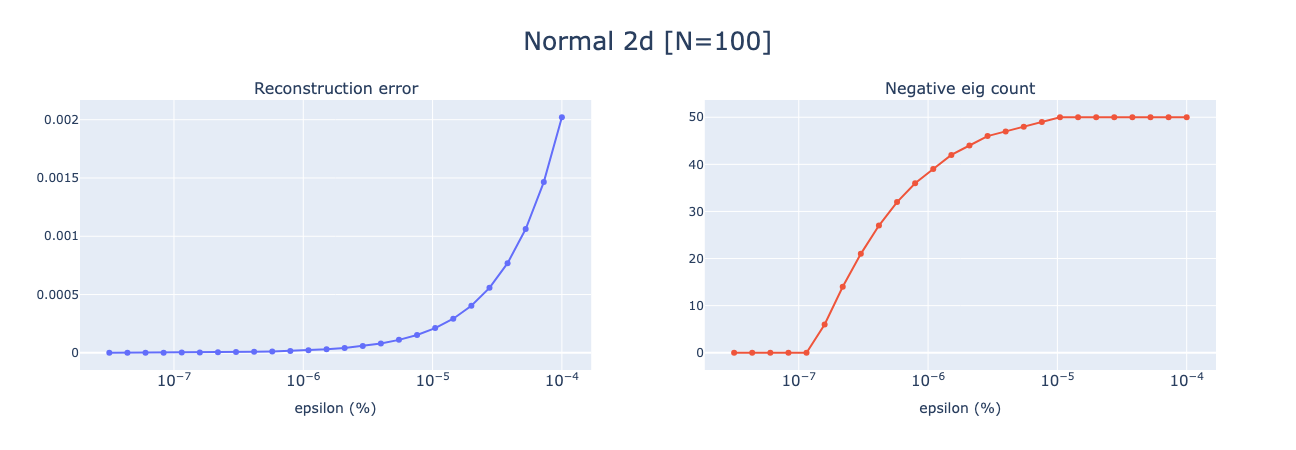

In [178]:
geometry = 'normal_2d'
epsilon_linspace, stats = explore_robustness(n=test_n, geometry=geometry, min_epsilon=min_epsilon, max_epsilon=max_epsilon, n_steps=n_steps)
plot_robustness_charts(epsilon_linspace, stats, title=f'{stats['name']} [N={test_n}]')

#### Normal 3d

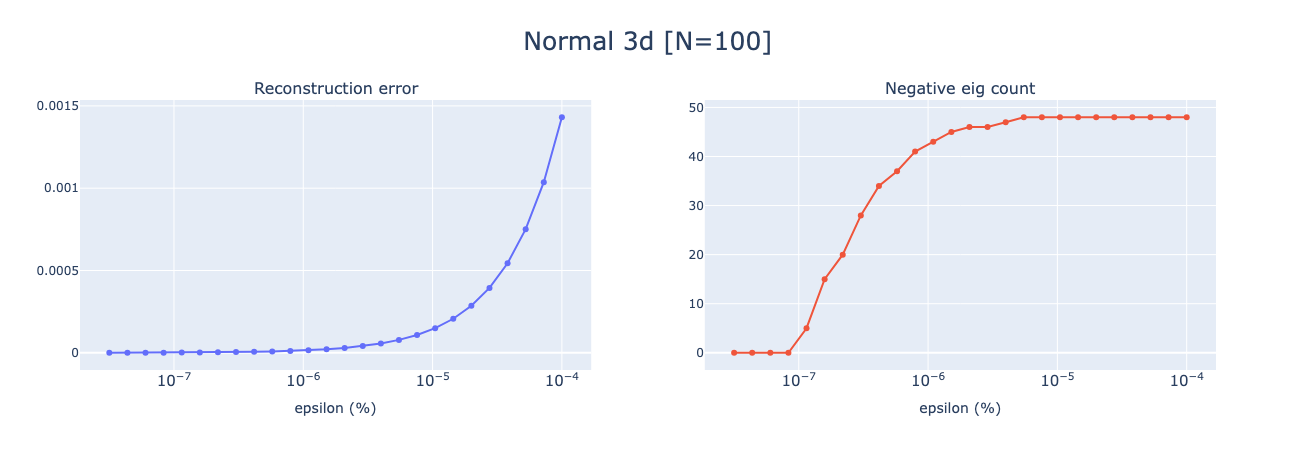

In [179]:
geometry = 'normal_3d'
epsilon_linspace, stats = explore_robustness(n=test_n, geometry=geometry, min_epsilon=min_epsilon, max_epsilon=max_epsilon, n_steps=n_steps)
plot_robustness_charts(epsilon_linspace, stats, title=f'{stats['name']} [N={test_n}]')

#### Circle

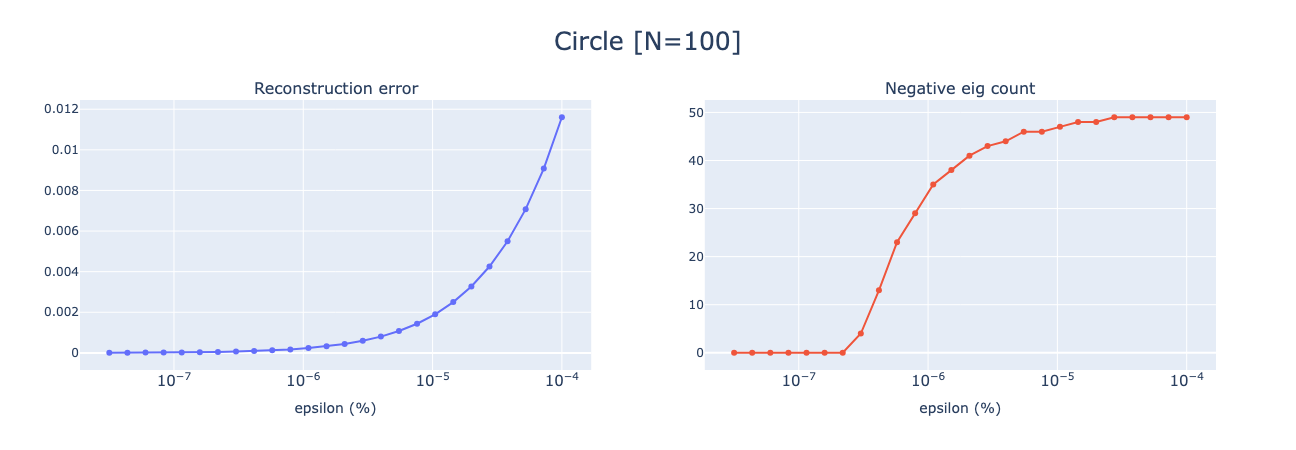

In [180]:
geometry = 'circle'
epsilon_linspace, stats = explore_robustness(n=test_n, geometry=geometry, min_epsilon=min_epsilon, max_epsilon=max_epsilon, n_steps=n_steps)
plot_robustness_charts(epsilon_linspace, stats, title=f'{stats['name']} [N={test_n}]')

#### Sphere

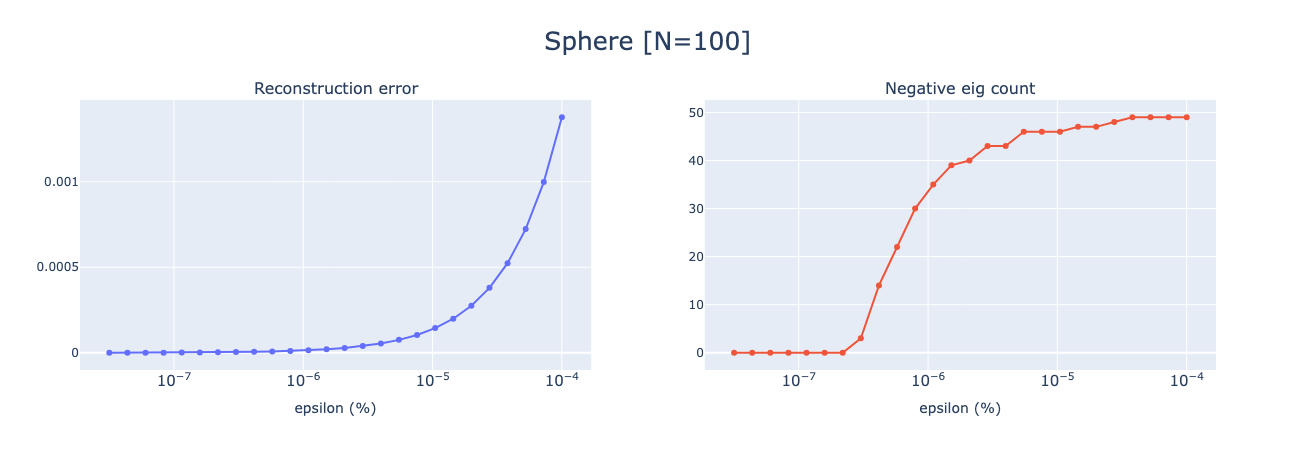

In [181]:
geometry = 'sphere'
epsilon_linspace, stats = explore_robustness(n=test_n, geometry=geometry, min_epsilon=min_epsilon, max_epsilon=max_epsilon, n_steps=n_steps)
plot_robustness_charts(epsilon_linspace, stats, title=f'{stats['name']} [N={test_n}]')

#### Line

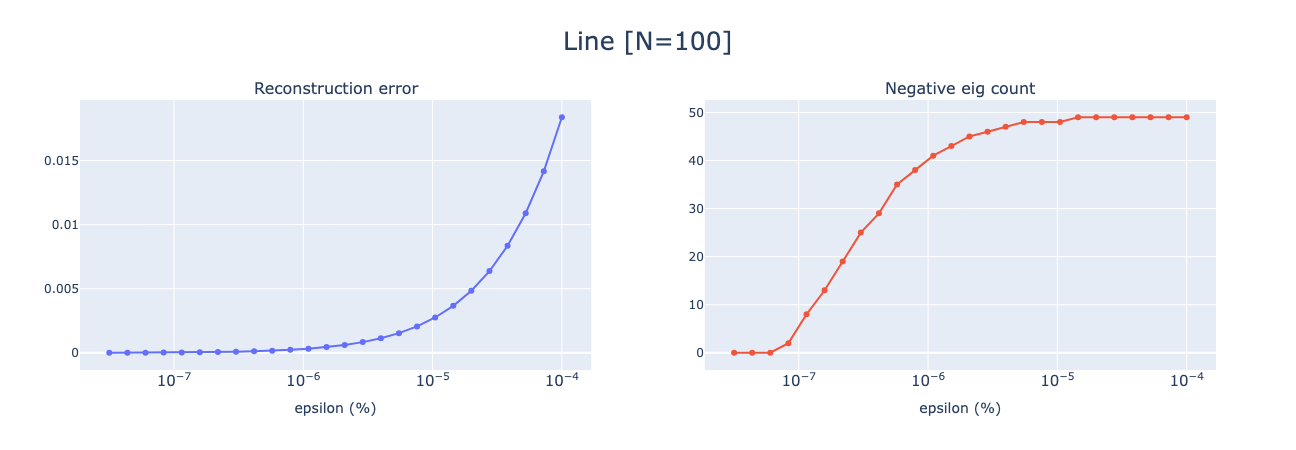

In [182]:
geometry = 'line'
epsilon_linspace, stats = explore_robustness(n=test_n, geometry=geometry, min_epsilon=min_epsilon, max_epsilon=max_epsilon, n_steps=n_steps)
plot_robustness_charts(epsilon_linspace, stats, title=f'{stats['name']} [N={test_n}]')

### Conclusions

На визуализациях можно увидеть, что **ошибка восстановления** растет линейно (у нас лог шкала) относительно ошибки, а вот количество отрицательных собственных значений имеют интересную тенденцию - на совсем маленьком шуме их количество равно 0 (что логично конечно), а потом медленно вырастает до ~половины от размерности и дальше могут только незначительно скакать. Почему выше половины не увеличивается - потому что матрица шума у нас симметричная и имеет нулевую диагональ (то есть нулевой след, то есть сумма собсвтенных значений)

## 7. Сравнение изометрического вложения и визуализации

In [ ]:
from scipy.stats import pearsonr

test_n_vis = 100
selected_cases = ['Normal 2d', 'Circle', 'Sphere', 'Normal 2d [Noise]', 'Circle [Noise]', 'Real']

matrices_vis, names_vis = get_all_test_matricies(n=test_n_vis)
matrices_by_name = dict(zip(names_vis, matrices_vis))

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle(r"Диаграмма $d_{ij}$ vs $\hat{d}_{ij}$ (2D вложение)", fontsize=14)

for ax, name in zip(axes.flat, selected_cases):
    D = matrices_by_name[name]
    D_hat = get_distance_matrix_from_points(create_coordinates(D, n_coordinates=2))

    idx = np.triu_indices(test_n_vis, k=1)
    d_orig = D[idx]
    d_rest = D_hat[idx]

    r, _ = pearsonr(d_orig, d_rest)

    lo, hi = d_orig.min(), d_orig.max()
    ax.scatter(d_orig, d_rest, alpha=0.25, s=5, c='steelblue')
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.2, label='ideal')
    ax.set_xlabel(r"$d_{ij}$  (original)")
    ax.set_ylabel(r"$\hat{d}_{ij}$  (2D restored)")
    ax.set_title(f"{name}\n$r = {r:.4f}$")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Вывод

Диаграмма $d_{ij}$ vs $\hat{d}_{ij}$ (2D вложение) позволяет визуально оценить качество изометрии:

- **Normal 2d** ($r \approx 1.0$): точки лежат строго на диагонали — данные изначально двумерные, вложение точное
- **Circle** ($r \approx 1.0$): окружность корректно вкладывается в 2D, хордовые расстояния сохраняются
- **Sphere** ($r < 1.0$): сильное рассеяние вокруг диагонали — 3D объект нельзя изометрически вложить в 2D без потерь
- **Шумные данные**: точки отклоняются от диагонали пропорционально уровню шума; $r$ падает
- **Реальные данные**: геодезические расстояния не евклидовы, вложение приближённое, но корреляция высокая для близких точек

**Вывод:** корреляция $r$ и визуальное отклонение от диагонали — взаимосвязанные меры качества. Случаи с $r \approx 1$ и точками на диагонали одновременно "хороши" и визуально, и метрически. Расхождение возникает, когда данные живут на неевклидовом многообразии (сфера, шумный граф) — тогда 2D визуализация геометрически искажает расстояния.